# exp_06 TMS 5-2: weight tying, subcomponents, faithfulness, and Figure-1-style geometry

This notebook analyzes the fixed `exp_06` SPD run at `spd_out/spd/s-faf4bc2e` using checkpoint `model_40000.pth`.

It covers:

1. confirming whether the target weights are tied (`W_2 = W_1^T`)
2. plotting cosine similarity between feature directions in `W_1` and `W_2^T`
3. visualizing all 20 SPD subcomponents for `linear1` and `linear2`
4. showing faithfulness by reconstructing each weight matrix from the top-norm subcomponents
5. producing a Figure-1-style 2D geometry view of the target weights, SPD reconstruction, top subcomponents, and the most causally important subcomponents under one-hot probes


## Setup order

Run the notebook from top to bottom, or use `Restart Kernel and Run All`.

The first executable cells do three things in order:

1. import the repo packages
2. define helper functions like `load_component_model(...)`
3. load the fixed run artifacts into `target_W1`, `spd_W1`, and the other analysis tensors

If you skip straight to a later cell after a fresh kernel, you will get `NameError` for notebook-defined helpers. That is a kernel-state issue, not an SPD installation issue.


In [1]:
import json
import sys
from pathlib import Path
import warnings


def find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'spd').exists() and (candidate / 'pyproject.toml').exists():
            return candidate
    raise FileNotFoundError('Could not find repo root from the current working directory.')


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

try:
    import seaborn as sns
    HAVE_SNS = True
except Exception:
    HAVE_SNS = False

from koko_experiments.parameter_recovery.tms_pretrained_analysis import (
    load_tms_target_model_from_spd_run,
)
from spd.configs import Config
from spd.models.component_model import ComponentModel
from spd.plotting import get_single_feature_causal_importances
from spd.utils.module_utils import expand_module_patterns

torch.set_grad_enabled(False)
plt.rcParams['figure.dpi'] = 140
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
if HAVE_SNS:
    sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.precision', 5)

warnings.filterwarnings('ignore', message='FigureCanvasAgg is non-interactive, and thus cannot be shown')
warnings.filterwarnings('ignore', message=r'set_ticklabels\(\) should only be used with a fixed number of ticks')

RUN_ID = 's-faf4bc2e'
CHECKPOINT_NAME = 'model_40000.pth'
INPUT_MAGNITUDE = 0.75
TOP_COMPONENTS_TO_SHOW = 6
TOP_K_FOR_RECONSTRUCTION = 5

RUN_DIR = REPO_ROOT / 'spd_out' / 'spd' / RUN_ID
CHECKPOINT_PATH = RUN_DIR / CHECKPOINT_NAME
TARGET_PATH = RUN_DIR / 'tms.pth'
FINAL_CONFIG_PATH = RUN_DIR / 'final_config.yaml'
METRICS_PATH = RUN_DIR / 'metrics.jsonl'

assert RUN_DIR.exists(), f'Missing run dir: {RUN_DIR}'
assert CHECKPOINT_PATH.exists(), f'Missing checkpoint: {CHECKPOINT_PATH}'
assert TARGET_PATH.exists(), f'Missing target model checkpoint: {TARGET_PATH}'
assert FINAL_CONFIG_PATH.exists(), f'Missing final_config.yaml: {FINAL_CONFIG_PATH}'
assert METRICS_PATH.exists(), f'Missing metrics.jsonl: {METRICS_PATH}'

print('Repo root:', REPO_ROOT)
print('Run dir:', RUN_DIR)
print('Checkpoint:', CHECKPOINT_PATH.name)
print('Target path:', TARGET_PATH)


def load_component_model(run_dir: Path, checkpoint_path: Path) -> tuple[Config, torch.nn.Module, ComponentModel]:
    config = Config.from_file(run_dir / 'final_config.yaml')
    target_model = load_tms_target_model_from_spd_run(run_dir)
    module_path_info = expand_module_patterns(target_model, config.all_module_info)
    component_model = ComponentModel(
        target_model=target_model,
        module_path_info=module_path_info,
        ci_config=config.ci_config,
        sigmoid_type=config.sigmoid_type,
        pretrained_model_output_attr=config.pretrained_model_output_attr,
    )
    state_dict = torch.load(checkpoint_path, map_location='cpu', weights_only=True)
    component_model.load_state_dict(state_dict)
    component_model.eval()
    return config, target_model, component_model


def read_jsonl(path: Path) -> list[dict[str, float]]:
    rows = []
    with path.open() as handle:
        for line in handle:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def as_numpy(x: torch.Tensor) -> np.ndarray:
    return x.detach().cpu().numpy()


def component_matrices(component_model: ComponentModel, layer_name: str) -> torch.Tensor:
    components = component_model.components[layer_name]
    return torch.einsum('ic,co->coi', components.V.detach().cpu(), components.U.detach().cpu())


def component_norms(component_stack: torch.Tensor) -> torch.Tensor:
    return torch.norm(component_stack.reshape(component_stack.shape[0], -1), dim=1)


def ranked_component_indices(component_stack: torch.Tensor) -> torch.Tensor:
    return component_norms(component_stack).argsort(descending=True)


def cumulative_reconstruction_df(
    component_stack: torch.Tensor,
    target_weight: torch.Tensor,
    layer_name: str,
) -> pd.DataFrame:
    order = ranked_component_indices(component_stack)
    running = torch.zeros_like(target_weight)
    target_norm = torch.norm(target_weight).item()
    rows = []
    for rank, component_idx in enumerate(order.tolist(), start=1):
        running = running + component_stack[component_idx]
        residual = target_weight - running
        rows.append(
            {
                'layer': layer_name,
                'k': rank,
                'component_idx': component_idx,
                'component_norm': float(torch.norm(component_stack[component_idx]).item()),
                'fro_error': float(torch.norm(residual).item()),
                'relative_fro_error': float(torch.norm(residual).item() / target_norm),
                'mse': float(torch.mean(residual.square()).item()),
            }
        )
    return pd.DataFrame(rows)


def cosine_similarity_matrix(a_rows: torch.Tensor, b_rows: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    a_unit = a_rows / a_rows.norm(dim=-1, keepdim=True).clamp_min(eps)
    b_unit = b_rows / b_rows.norm(dim=-1, keepdim=True).clamp_min(eps)
    return a_unit @ b_unit.T


def plot_heatmap(ax: plt.Axes, matrix: torch.Tensor, title: str, xlabels: list[str], ylabels: list[str]) -> None:
    matrix_np = as_numpy(matrix)
    if HAVE_SNS:
        sns.heatmap(
            matrix_np,
            annot=True,
            fmt='.3f',
            cmap='RdBu_r',
            vmin=-1.0,
            vmax=1.0,
            square=True,
            cbar=True,
            cbar_kws={'label': 'cosine similarity'},
            ax=ax,
        )
    else:
        im = ax.imshow(matrix_np, cmap='RdBu_r', vmin=-1.0, vmax=1.0)
        for row in range(matrix_np.shape[0]):
            for col in range(matrix_np.shape[1]):
                ax.text(col, row, f'{matrix_np[row, col]:.3f}', ha='center', va='center')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='cosine similarity')
    ax.set_title(title)
    ax.set_xlabel('W2^T feature direction index')
    ax.set_ylabel('W1 feature direction index')
    tick_x = np.arange(len(xlabels)) + 0.5 if HAVE_SNS else np.arange(len(xlabels))
    tick_y = np.arange(len(ylabels)) + 0.5 if HAVE_SNS else np.arange(len(ylabels))
    ax.set_xticks(tick_x, labels=xlabels)
    ax.set_yticks(tick_y, labels=ylabels)
    ax.tick_params(axis='x', rotation=0)
    ax.tick_params(axis='y', rotation=0)


def plot_component_grid(component_stack: torch.Tensor, layer_name: str, order: torch.Tensor | None = None) -> None:
    order = torch.arange(component_stack.shape[0]) if order is None else order
    n_components = component_stack.shape[0]
    ncols = 5
    nrows = int(np.ceil(n_components / ncols))
    vmax = float(component_stack.abs().max().item())
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 2.4 * nrows))
    axes = np.atleast_1d(axes).reshape(nrows, ncols)
    for panel_idx, ax in enumerate(axes.flat):
        if panel_idx >= n_components:
            ax.axis('off')
            continue
        component_idx = int(order[panel_idx].item())
        component_matrix = component_stack[component_idx]
        im = ax.imshow(as_numpy(component_matrix), cmap='coolwarm', vmin=-vmax, vmax=vmax)
        ax.set_title(f'{layer_name} c={component_idx}\n||W_c||={torch.norm(component_matrix).item():.3f}')
        ax.set_xticks(range(component_matrix.shape[1]))
        ax.set_yticks(range(component_matrix.shape[0]))
    fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.015, pad=0.01, label='weight value')
    fig.suptitle(f'{layer_name}: all {n_components} rank-one SPD subcomponents', y=1.02)
    fig.tight_layout()
    plt.show()


def plot_weight_matrix(ax: plt.Axes, matrix: torch.Tensor, title: str, vmax: float) -> None:
    im = ax.imshow(as_numpy(matrix), cmap='coolwarm', vmin=-vmax, vmax=vmax)
    ax.set_title(title)
    ax.set_xticks(range(matrix.shape[1]))
    ax.set_yticks(range(matrix.shape[0]))
    return im


def vector_plot_limit(vector_groups: list[torch.Tensor]) -> float:
    max_abs = max(float(group.abs().max().item()) for group in vector_groups)
    return 1.15 * max_abs


def plot_vector_panel(
    ax: plt.Axes,
    feature_vectors: torch.Tensor,
    colors: list,
    title: str,
    limit: float,
    highlight_feature: int | None = None,
    reference_vectors: torch.Tensor | None = None,
) -> None:
    ax.axhline(0.0, color='#cccccc', linewidth=0.8)
    ax.axvline(0.0, color='#cccccc', linewidth=0.8)
    if highlight_feature is not None and reference_vectors is not None:
        ref = reference_vectors[highlight_feature]
        ax.plot([0.0, ref[0].item()], [0.0, ref[1].item()], linestyle='--', color='black', linewidth=1.5, alpha=0.8)
    for feature_idx, vector in enumerate(feature_vectors):
        alpha = 1.0 if highlight_feature is None or feature_idx == highlight_feature else 0.18
        linewidth = 3.0 if highlight_feature is not None and feature_idx == highlight_feature else 2.0
        ax.plot([0.0, vector[0].item()], [0.0, vector[1].item()], color=colors[feature_idx], linewidth=linewidth, alpha=alpha)
        ax.scatter(vector[0].item(), vector[1].item(), s=45, color=colors[feature_idx], alpha=alpha)
        ax.text(vector[0].item() * 1.05, vector[1].item() * 1.05, f'f{feature_idx}', color=colors[feature_idx], fontsize=10, alpha=alpha)
    ax.set_aspect('equal')
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)


# Keep analysis weights as torch.Tensor for all math and equality checks.
# Convert to NumPy only inside plotting helpers via `as_numpy(...)`.
config, target_model, component_model = load_component_model(RUN_DIR, CHECKPOINT_PATH)

target_W1 = target_model.linear1.weight.detach().cpu()
target_W2 = target_model.linear2.weight.detach().cpu()
spd_W1 = component_model.components['linear1'].weight.detach().cpu()
spd_W2 = component_model.components['linear2'].weight.detach().cpu()
linear1_components = component_matrices(component_model, 'linear1')
linear2_components = component_matrices(component_model, 'linear2')
linear1_order = ranked_component_indices(linear1_components)
linear2_order = ranked_component_indices(linear2_components)

metrics_rows = read_jsonl(METRICS_PATH) if METRICS_PATH.exists() else []
latest_metrics = metrics_rows[-1] if metrics_rows else {}

run_summary = pd.Series(
    {
        'run_id': RUN_DIR.name,
        'checkpoint': CHECKPOINT_PATH.name,
        'n_features': target_model.config.n_features,
        'n_hidden': target_model.config.n_hidden,
        'linear1_C': linear1_components.shape[0],
        'linear2_C': linear2_components.shape[0],
        'target_tied_weights': bool(target_model.config.tied_weights),
        'final_faithfulness_loss': latest_metrics.get('loss/FaithfulnessLoss', float('nan')),
        'final_unmasked_recon_loss': latest_metrics.get('loss/UnmaskedReconLoss', float('nan')),
    }
)
display(run_summary)


/Users/abdulhakeemadefioye/Desktop/deep-learning/koko_spd/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Repo root: /Users/abdulhakeemadefioye/Desktop/deep-learning/koko_spd
Run dir: /Users/abdulhakeemadefioye/Desktop/deep-learning/koko_spd/spd_out/spd/s-faf4bc2e
Checkpoint: model_40000.pth
Target path: /Users/abdulhakeemadefioye/Desktop/deep-learning/koko_spd/spd_out/spd/s-faf4bc2e/tms.pth


run_id                            s-faf4bc2e
checkpoint                   model_40000.pth
n_features                                 5
n_hidden                                   2
linear1_C                                 20
linear2_C                                 20
target_tied_weights                     True
final_faithfulness_loss                  0.0
final_unmasked_recon_loss                0.0
dtype: object

## Tensor vs NumPy convention

- `target_W1`, `target_W2`, `spd_W1`, and `spd_W2` stay as `torch.Tensor` values.
- All comparisons, norms, cosine similarities, and reconstructions should use tensors.
- Only plotting helpers convert tensors to NumPy, using `as_numpy(...)` at the visualization boundary.


## Key Findings

- The target model weights are exactly tied: `W2 = W1^T` with `max_abs_diff = 0.0` and `fro_diff = 0.0`.
- The SPD decomposition preserves that tie exactly both in the summed weights and component-by-component.
- The cosine-similarity matrix between feature directions in `W1` and `W2^T` is an identity matching: each feature matches the same-index feature with cosine `1.0`.
- The decomposition is strongly sparse in practice: five components dominate the norm mass, with the next fifteen much smaller.
- The top causally important `linear1` components selected by one-hot probes are `c4, c1, c8, c7, c13`, one unique component per feature.
- Full reconstruction error is effectively zero at this checkpoint: `full_sum_mse = 4.68153e-09` for both `linear1` and `linear2`.
- The top-5 components recover most of the visible geometry, while around top-10 components are needed to drive relative Frobenius error below `1e-1`.


## 1. Confirm whether the target and SPD weights are tied

In [ ]:
target_tie_diff = target_W2 - target_W1.T
spd_sum_tie_diff = spd_W2 - spd_W1.T
spd_component_tie_diff = linear2_components - linear1_components.transpose(-1, -2)

tied_summary = pd.DataFrame(
    [
        {
            'object': 'target weights',
            'is_transpose_tied': torch.allclose(target_W2, target_W1.T, atol=1e-6, rtol=1e-5),
            'max_abs_diff': float(target_tie_diff.abs().max().item()),
            'fro_diff': float(torch.norm(target_tie_diff).item()),
        },
        {
            'object': 'SPD summed weights',
            'is_transpose_tied': torch.allclose(spd_W2, spd_W1.T, atol=1e-6, rtol=1e-5),
            'max_abs_diff': float(spd_sum_tie_diff.abs().max().item()),
            'fro_diff': float(torch.norm(spd_sum_tie_diff).item()),
        },
        {
            'object': 'SPD component matrices',
            'is_transpose_tied': torch.allclose(linear2_components, linear1_components.transpose(-1, -2), atol=1e-6, rtol=1e-5),
            'max_abs_diff': float(spd_component_tie_diff.abs().max().item()),
            'fro_diff': float(torch.norm(spd_component_tie_diff).item()),
        },
    ]
)
display(tied_summary)

print('Target W1 shape:', tuple(target_W1.shape))
print('Target W2 shape:', tuple(target_W2.shape))
print('Target W1:')
print(target_W1)
print('Target W2:')
print(target_W2)

,object,is_transpose_tied,max_abs_diff,fro_diff
0,target weights,True,0.0,0.0
1,SPD summed weights,True,0.0,0.0
2,SPD component matrices,True,0.0,0.0


Target W1 shape: (2, 5)
Target W2 shape: (5, 2)
Target W1:
tensor([[ 0.8253,  0.9843, -0.4904, -0.1874, -1.1319],
        [ 0.7684, -0.5487,  1.0253, -1.1113, -0.1662]])
Target W2:
tensor([[ 0.8253,  0.7684],
        [ 0.9843, -0.5487],
        [-0.4904,  1.0253],
        [-0.1874, -1.1113],
        [-1.1319, -0.1662]])


: 

: 

In [ ]:
# Cast spd_W1 and spd_W2 to tensors so I can get the shapes
spd_W1_tensor = torch.tensor(spd_W1)
spd_W2_tensor = torch.tensor(spd_W2)
print('SPD W1 shape:', tuple(spd_W1_tensor.shape))
print('SPD W2 shape:', tuple(spd_W2_tensor.shape))

SPD W1 shape: (2, 5)
SPD W2 shape: (5, 2)


/var/folders/x0/2gdcc4dx06l26j8346nm7c5r0000gn/T/ipykernel_84012/1497676564.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  spd_W1_tensor = torch.tensor(spd_W1)
/var/folders/x0/2gdcc4dx06l26j8346nm7c5r0000gn/T/ipykernel_84012/1497676564.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  spd_W2_tensor = torch.tensor(spd_W2)


: 

: 

In [ ]:
print('SPD weights:')
print(spd_W1, end='\n')
print(spd_W2.T)
print('--------------------------------')
print("Target weights:")
print(target_W1, end='\n')
print(target_W2.T)

SPD weights:
tensor([[ 0.8254,  0.9844, -0.4904, -0.1874, -1.1320],
        [ 0.7684, -0.5487,  1.0254, -1.1114, -0.1662]])
tensor([[ 0.8254,  0.9844, -0.4904, -0.1874, -1.1320],
        [ 0.7684, -0.5487,  1.0254, -1.1114, -0.1662]])
--------------------------------
Target weights:
tensor([[ 0.8253,  0.9843, -0.4904, -0.1874, -1.1319],
        [ 0.7684, -0.5487,  1.0253, -1.1113, -0.1662]])
tensor([[ 0.8253,  0.9843, -0.4904, -0.1874, -1.1319],
        [ 0.7684, -0.5487,  1.0253, -1.1113, -0.1662]])


: 

: 

#### Explore subcomponents

In [ ]:
top_5_linear1 = linear1_components[linear1_order[:TOP_K_FOR_RECONSTRUCTION]]
top_5_linear2 = linear2_components[linear2_order[:TOP_K_FOR_RECONSTRUCTION]]
linear1_sum = linear1_components.sum(dim=0)
linear1_sum

tensor([[ 0.8254,  0.9844, -0.4904, -0.1874, -1.1320],
        [ 0.7684, -0.5487,  1.0254, -1.1114, -0.1662]])

: 

: 

## 2. Cosine similarity between feature directions in `W1` and `W2^T`

,W1_feature,best_match_in_W2T,best_cosine
0,0,0,1.0
1,1,1,1.0
2,2,2,1.0
3,3,3,1.0
4,4,4,1.0


Best-match indices are unique: True


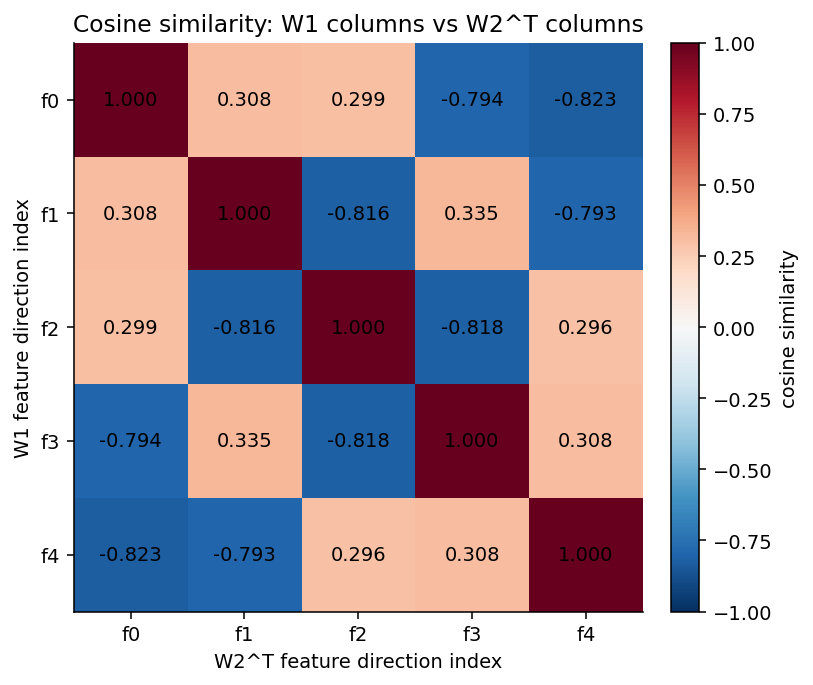

: 

: 

In [ ]:
w1_feature_directions = target_W1.T
w2t_feature_directions = target_W2
cosine_matrix = cosine_similarity_matrix(w1_feature_directions, w2t_feature_directions)

cosine_matches = pd.DataFrame(
    {
        'W1_feature': list(range(target_model.config.n_features)),
        'best_match_in_W2T': cosine_matrix.argmax(dim=1).tolist(),
        'best_cosine': cosine_matrix.max(dim=1).values.tolist(),
    }
)
display(cosine_matches)
print('Best-match indices are unique:', cosine_matches['best_match_in_W2T'].nunique() == len(cosine_matches))

fig, ax = plt.subplots(figsize=(6, 5))
labels = [f'f{i}' for i in range(target_model.config.n_features)]
plot_heatmap(ax, cosine_matrix, 'Cosine similarity: W1 columns vs W2^T columns', labels, labels)
fig.tight_layout()
plt.show()

## 3. All 20 SPD subcomponents for `W1` and `W2`

/var/folders/x0/2gdcc4dx06l26j8346nm7c5r0000gn/T/ipykernel_84012/4181469551.py:202: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


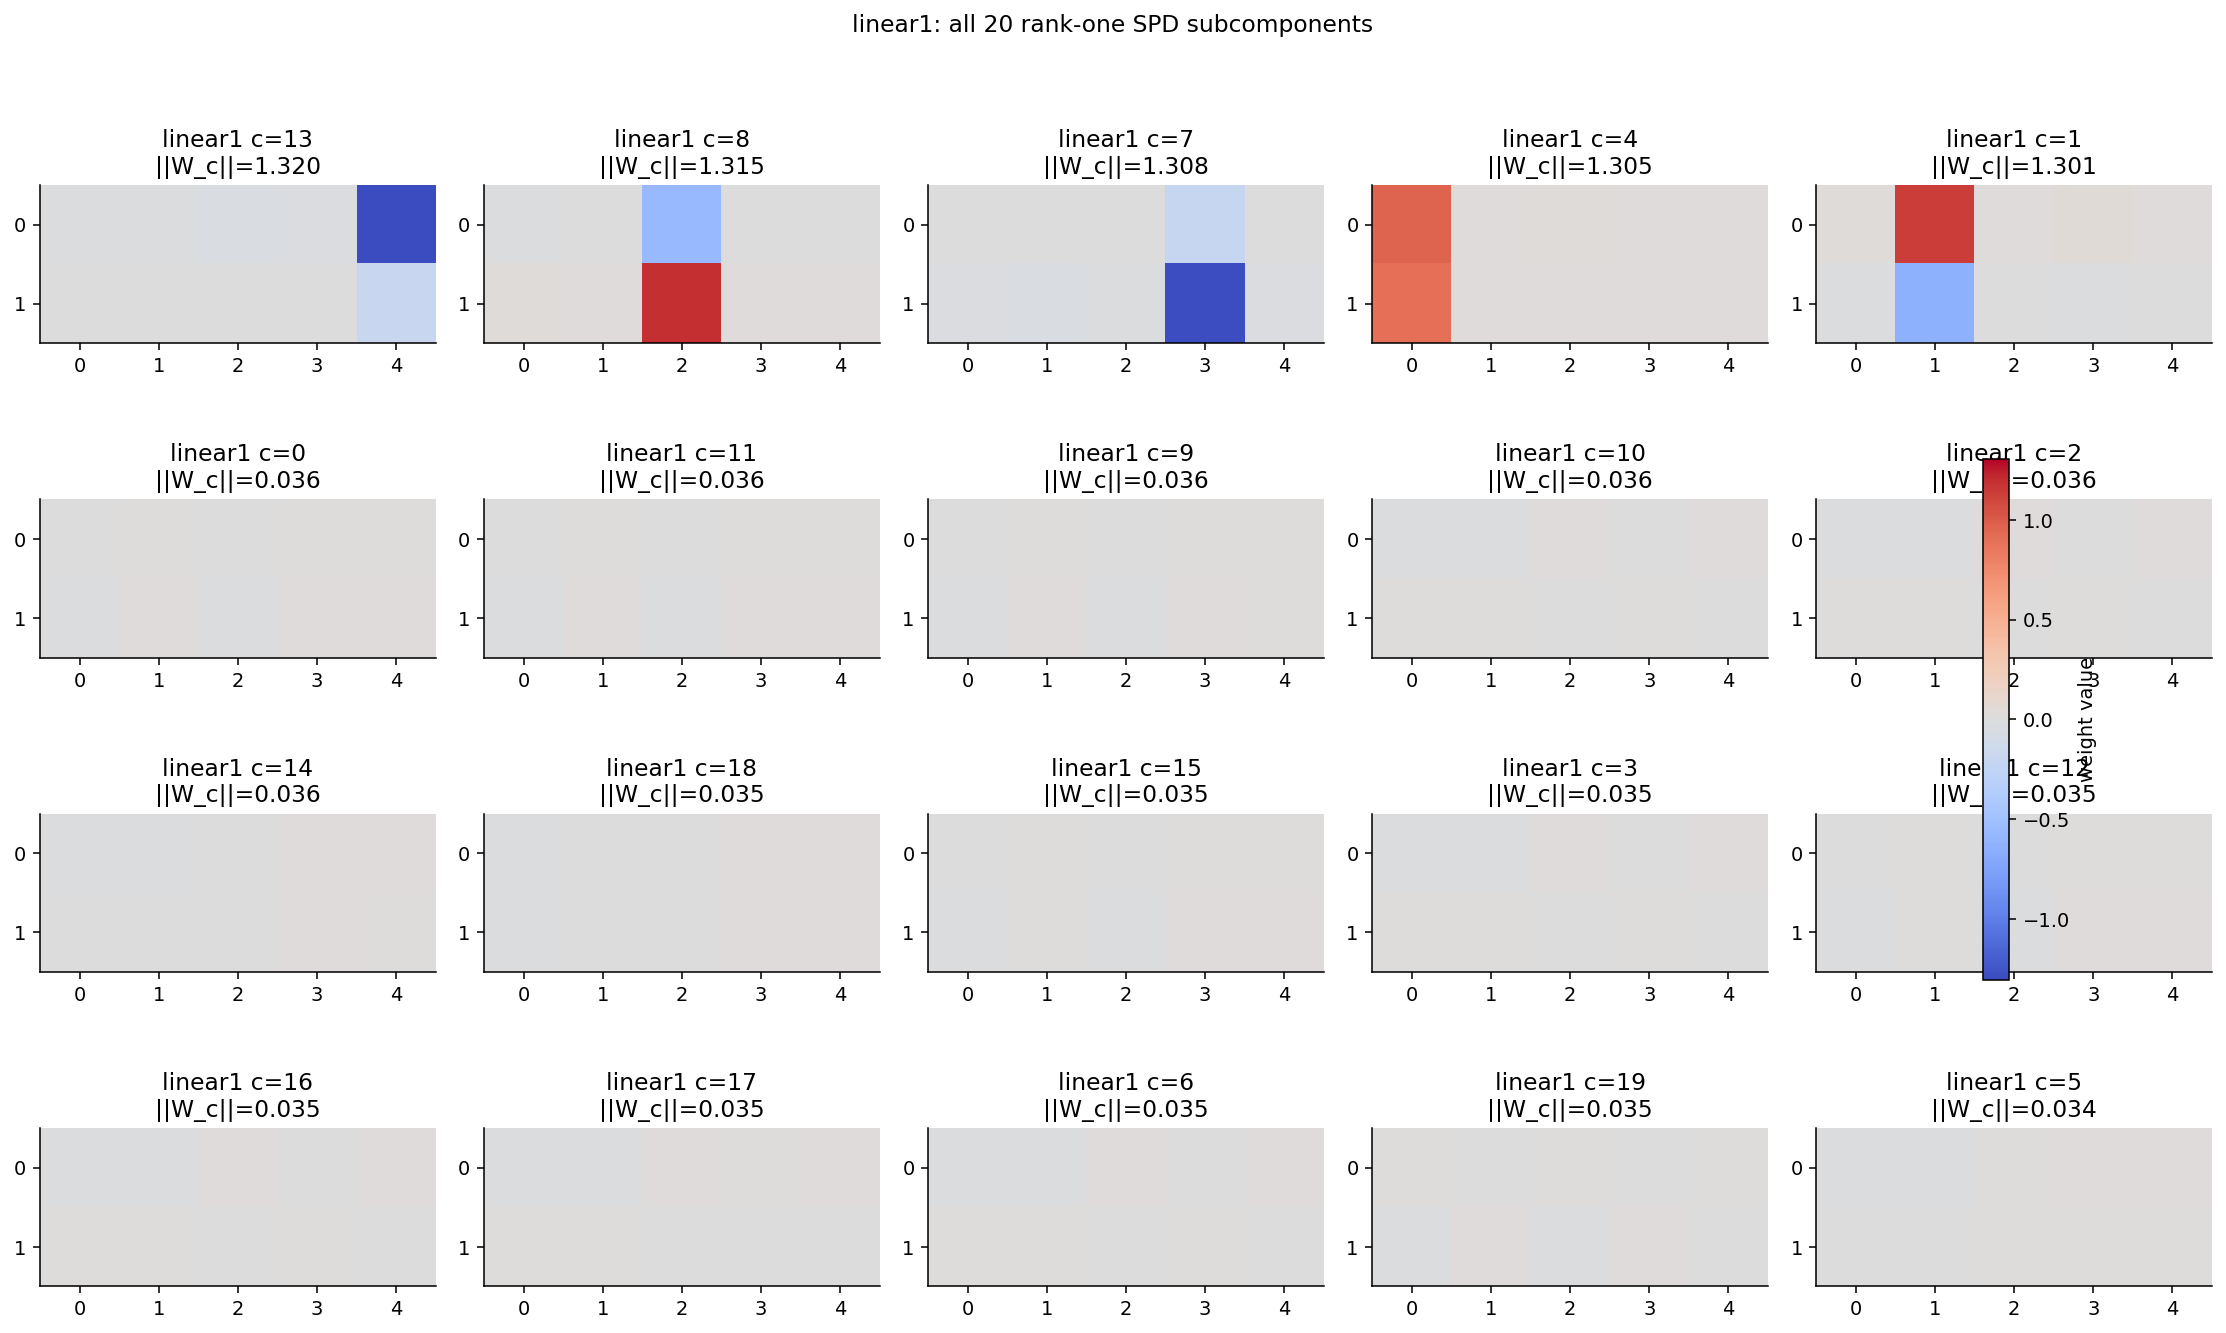

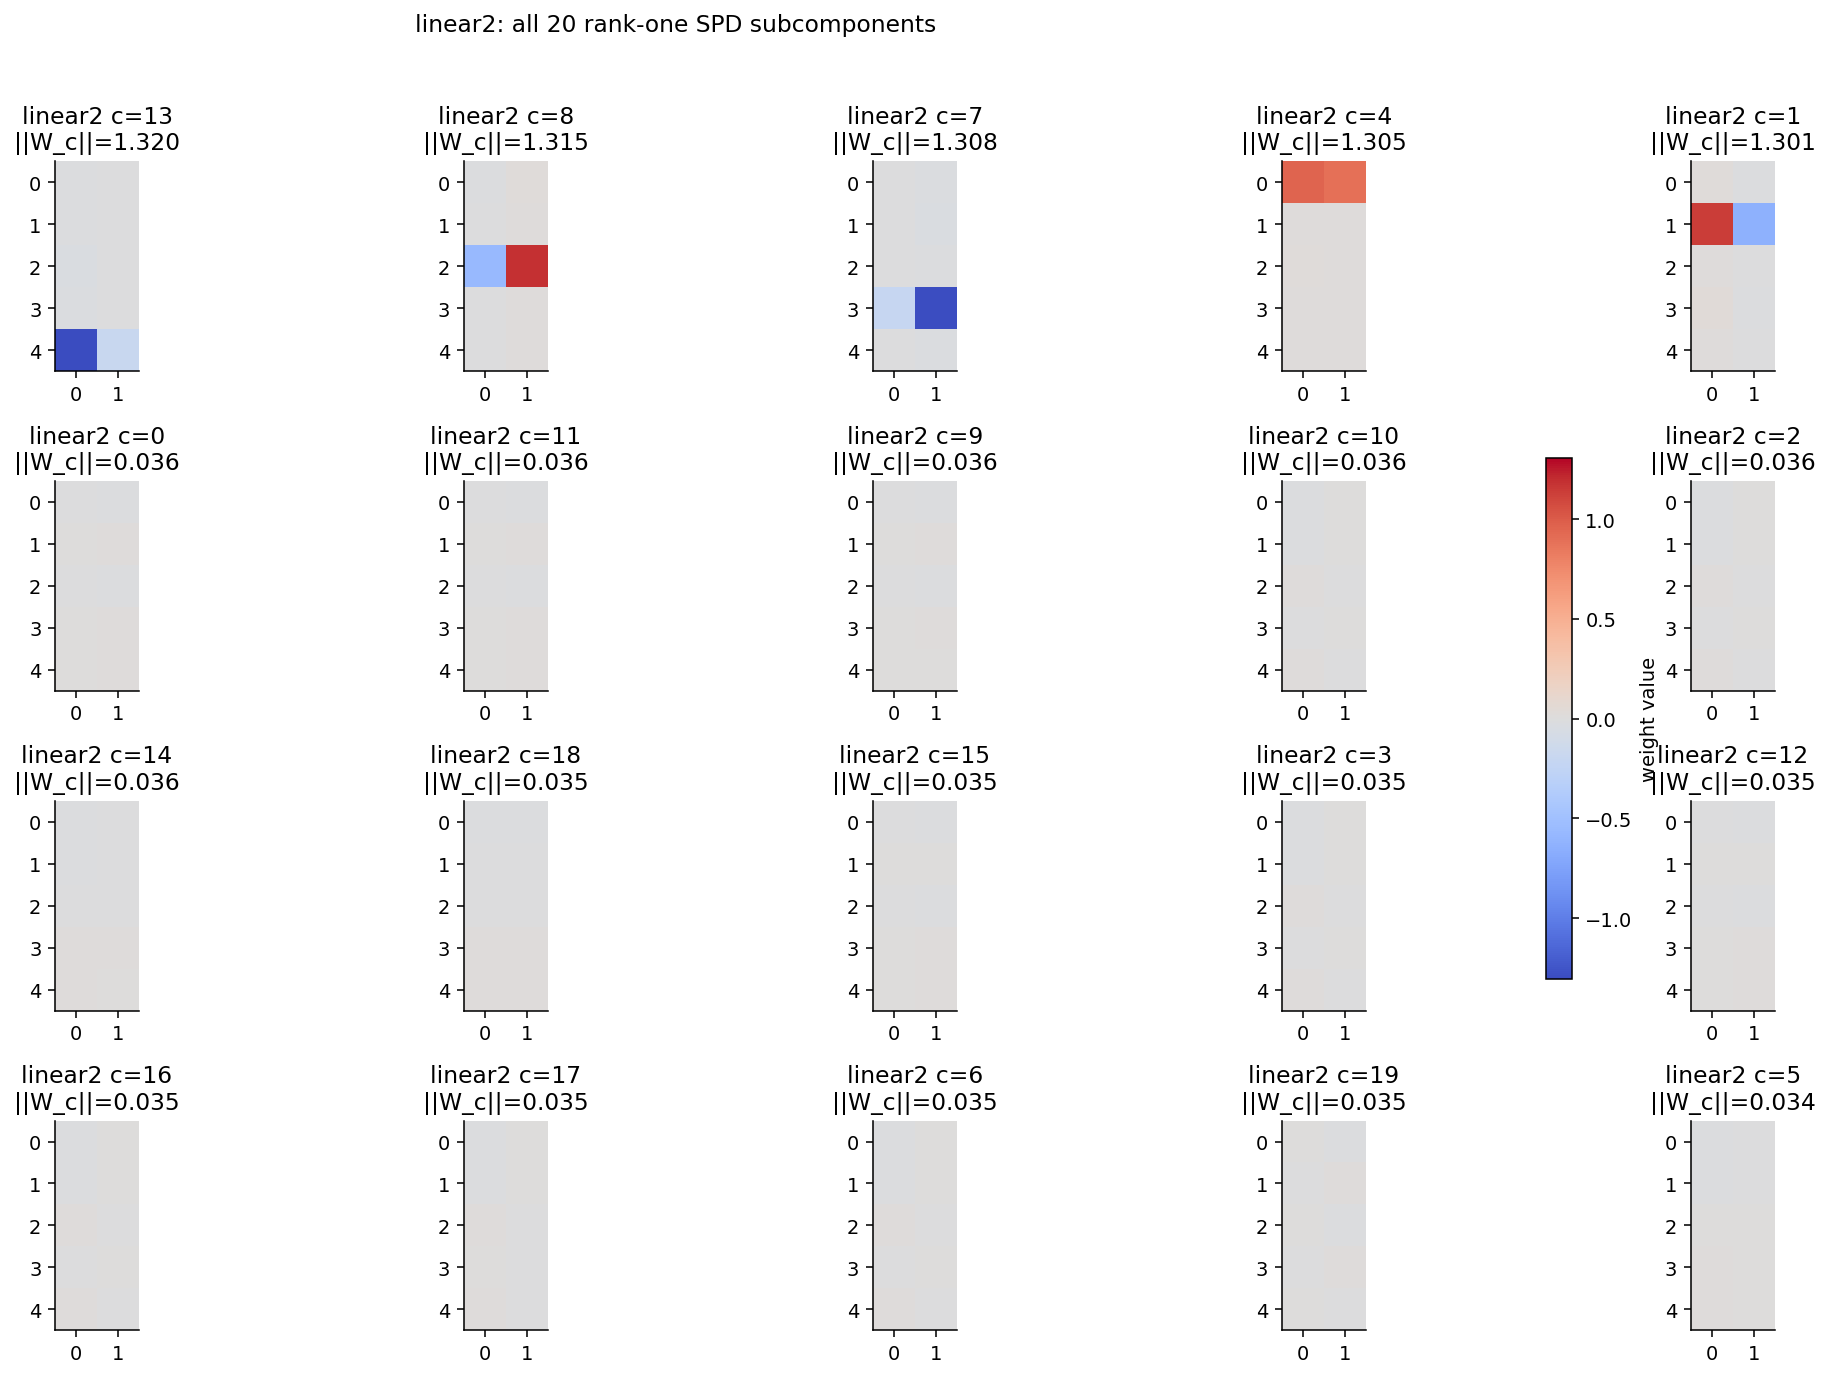

: 

: 

In [ ]:
plot_component_grid(linear1_components, 'linear1', order=linear1_order)
plot_component_grid(linear2_components, 'linear2', order=linear2_order)

## 4. Faithfulness from top-norm subcomponents

,layer,k_for_rel_error<=1e-01,k_for_rel_error<=1e-02,k_for_rel_error<=1e-03,k_for_rel_error<=1e-04,full_sum_mse,top5_mse
0,linear1,10,20,20,20,4.68153e-09,0.01362
1,linear2,10,20,20,20,4.68153e-09,0.01362


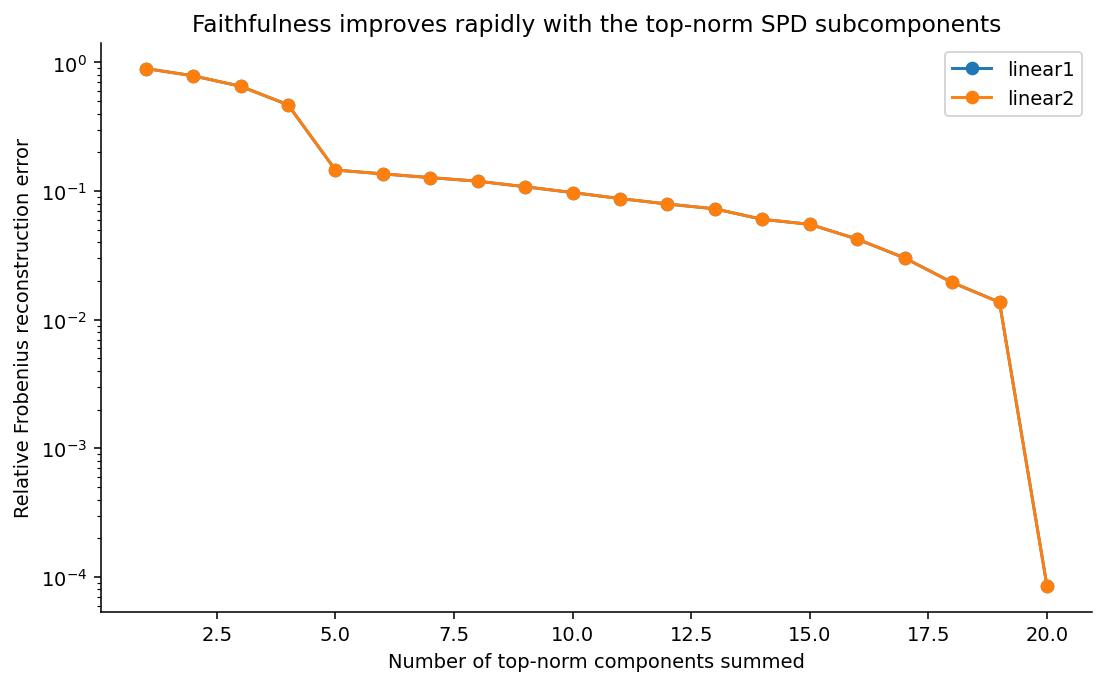

: 

: 

In [ ]:
linear1_faithfulness = cumulative_reconstruction_df(linear1_components, target_W1, 'linear1')
linear2_faithfulness = cumulative_reconstruction_df(linear2_components, target_W2, 'linear2')
faithfulness_df = pd.concat([linear1_faithfulness, linear2_faithfulness], ignore_index=True)

threshold_rows = []
for layer_name, layer_df in faithfulness_df.groupby('layer'):
    row = {'layer': layer_name}
    for threshold in [1e-1, 1e-2, 1e-3, 1e-4]:
        passing = layer_df[layer_df['relative_fro_error'] <= threshold]
        row[f'k_for_rel_error<={threshold:.0e}'] = int(passing.iloc[0]['k']) if len(passing) > 0 else None
    row['full_sum_mse'] = float(layer_df.iloc[-1]['mse'])
    row['top5_mse'] = float(layer_df.iloc[TOP_K_FOR_RECONSTRUCTION - 1]['mse'])
    threshold_rows.append(row)
threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)

fig, ax = plt.subplots(figsize=(8, 5))
for layer_name, layer_df in faithfulness_df.groupby('layer'):
    ax.plot(layer_df['k'], layer_df['relative_fro_error'], marker='o', label=layer_name)
ax.set_yscale('log')
ax.set_xlabel('Number of top-norm components summed')
ax.set_ylabel('Relative Frobenius reconstruction error')
ax.set_title('Faithfulness improves rapidly with the top-norm SPD subcomponents')
ax.legend()
fig.tight_layout()
plt.show()


/var/folders/x0/2gdcc4dx06l26j8346nm7c5r0000gn/T/ipykernel_84012/1201812001.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


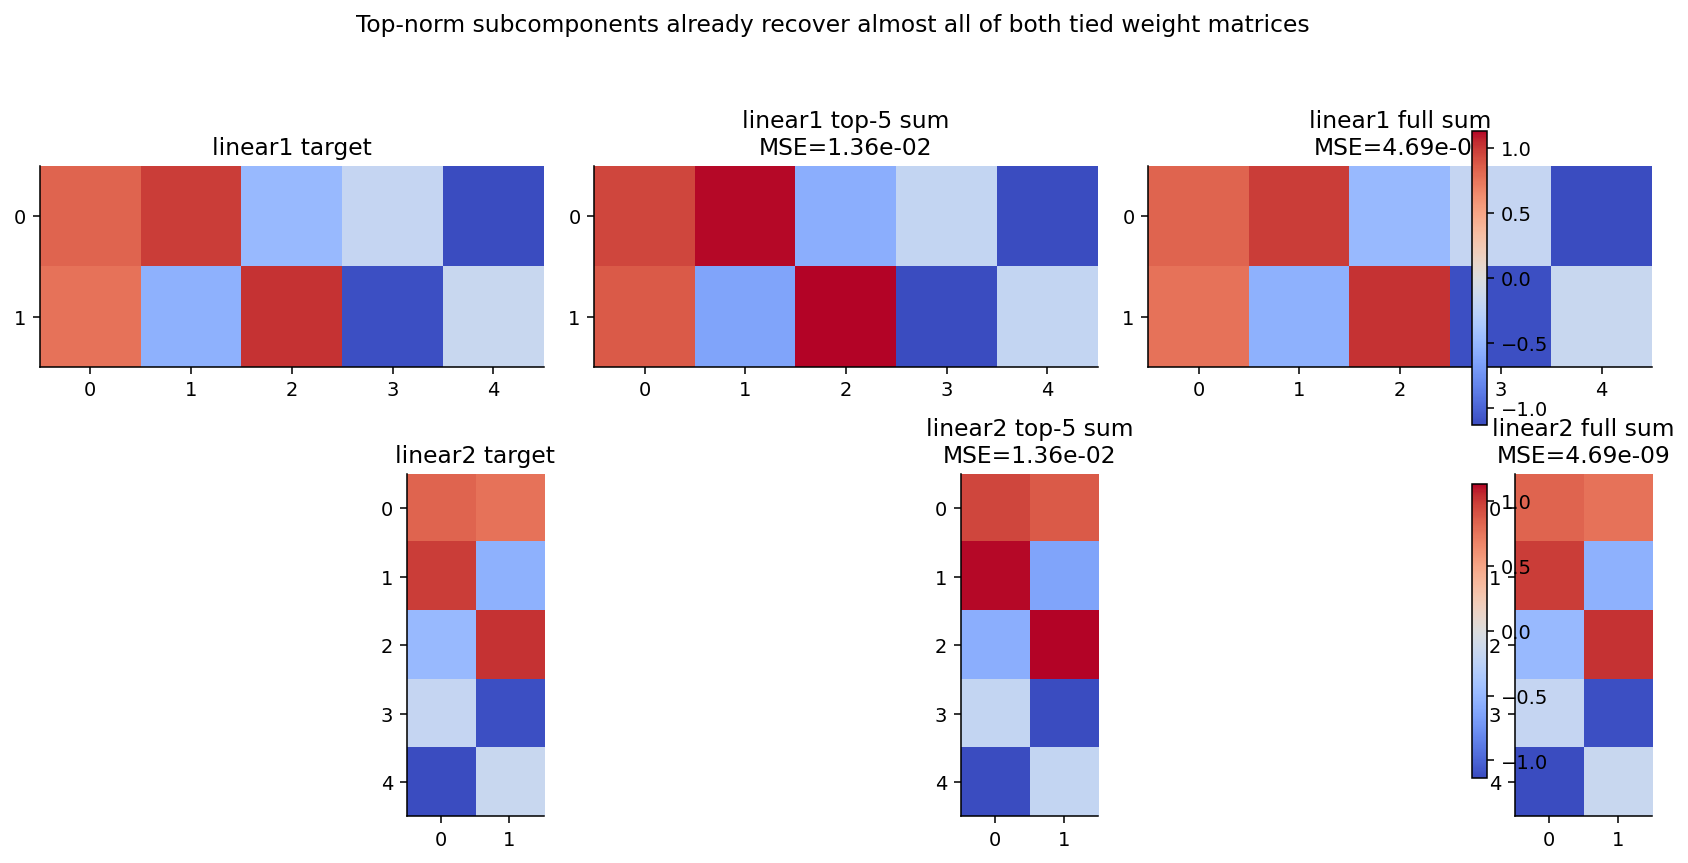

: 

: 

In [ ]:
top5_linear1 = linear1_components[linear1_order[:TOP_K_FOR_RECONSTRUCTION]].sum(dim=0)
top5_linear2 = linear2_components[linear2_order[:TOP_K_FOR_RECONSTRUCTION]].sum(dim=0)
full_linear1 = linear1_components.sum(dim=0)
full_linear2 = linear2_components.sum(dim=0)

fig, axes = plt.subplots(2, 3, figsize=(12, 6))

linear1_vmax = float(torch.max(torch.abs(target_W1.min()), torch.abs(target_W1.max())).item())
linear2_vmax = float(torch.max(torch.abs(target_W2.min()), torch.abs(target_W2.max())).item())

im = plot_weight_matrix(axes[0, 0], target_W1, 'linear1 target', linear1_vmax)
plot_weight_matrix(axes[0, 1], top5_linear1, f'linear1 top-{TOP_K_FOR_RECONSTRUCTION} sum\nMSE={torch.mean((top5_linear1 - target_W1).square()).item():.2e}', linear1_vmax)
plot_weight_matrix(axes[0, 2], full_linear1, f'linear1 full sum\nMSE={torch.mean((full_linear1 - target_W1).square()).item():.2e}', linear1_vmax)
fig.colorbar(im, ax=axes[0, :].tolist(), fraction=0.025, pad=0.02)

im = plot_weight_matrix(axes[1, 0], target_W2, 'linear2 target', linear2_vmax)
plot_weight_matrix(axes[1, 1], top5_linear2, f'linear2 top-{TOP_K_FOR_RECONSTRUCTION} sum\nMSE={torch.mean((top5_linear2 - target_W2).square()).item():.2e}', linear2_vmax)
plot_weight_matrix(axes[1, 2], full_linear2, f'linear2 full sum\nMSE={torch.mean((full_linear2 - target_W2).square()).item():.2e}', linear2_vmax)
fig.colorbar(im, ax=axes[1, :].tolist(), fraction=0.025, pad=0.02)

fig.suptitle('Top-norm subcomponents already recover almost all of both tied weight matrices', y=1.02)
fig.tight_layout()
plt.show()

## 5. Figure-1-style 2D geometry and CI-selected components

In [ ]:
ci_outputs = get_single_feature_causal_importances(
    model=component_model,
    batch_shape=(target_model.config.n_features, target_model.config.n_features),
    input_magnitude=INPUT_MAGNITUDE,
    sampling='lower_leaky',
)
ci_linear1 = ci_outputs.lower_leaky['linear1'].detach().cpu()
ci_linear2 = ci_outputs.lower_leaky['linear2'].detach().cpu()

ci_rows = []
for feature_idx in range(target_model.config.n_features):
    best_linear1 = int(ci_linear1[feature_idx].argmax().item())
    best_linear2 = int(ci_linear2[feature_idx].argmax().item())
    ci_rows.append(
        {
            'feature': feature_idx,
            'linear1_best_component': best_linear1,
            'linear1_ci': float(ci_linear1[feature_idx, best_linear1].item()),
            'linear2_best_component': best_linear2,
            'linear2_ci': float(ci_linear2[feature_idx, best_linear2].item()),
            'same_component_across_layers': best_linear1 == best_linear2,
        }
    )
ci_df = pd.DataFrame(ci_rows)
display(ci_df)
print('Unique CI-selected linear1 components:', ci_df['linear1_best_component'].nunique())


,feature,linear1_best_component,linear1_ci,linear2_best_component,linear2_ci,same_component_across_layers
0,0,4,0.84824,4,0.85736,True
1,1,1,0.85255,1,0.84922,True
2,2,8,0.85566,8,0.85532,True
3,3,7,0.85397,7,0.85895,True
4,4,13,0.86187,13,0.86267,True


Unique CI-selected linear1 components: 5


: 

: 

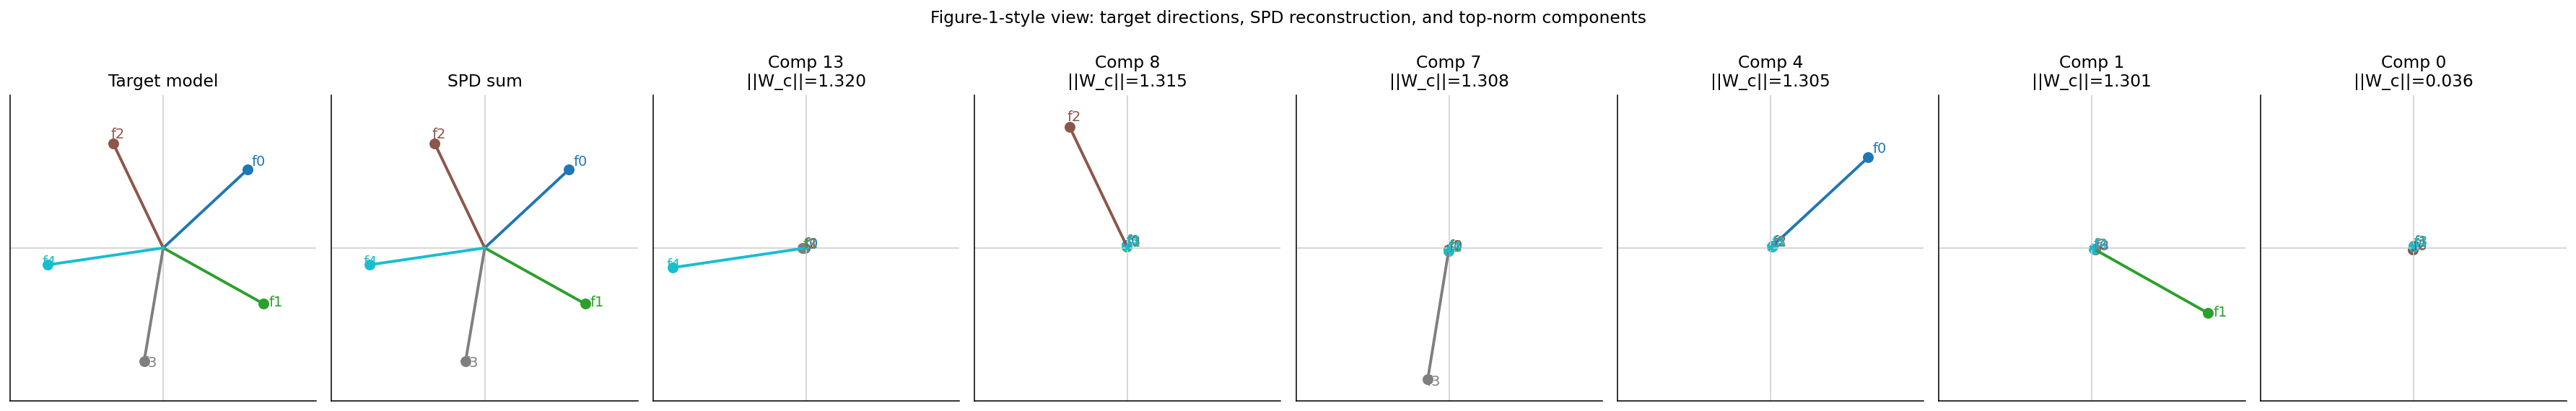

: 

: 

In [ ]:
feature_colors = list(plt.colormaps['tab10'](np.linspace(0, 1, target_model.config.n_features)))
target_vectors = target_W1.T
spd_sum_vectors = full_linear1.T
top_component_indices = linear1_order[:TOP_COMPONENTS_TO_SHOW].tolist()
top_component_vectors = [linear1_components[idx].T for idx in top_component_indices]
plot_limit = vector_plot_limit([target_vectors, spd_sum_vectors, *top_component_vectors])

fig, axes = plt.subplots(1, 2 + len(top_component_indices), figsize=(3.2 * (2 + len(top_component_indices)), 4.0))
plot_vector_panel(axes[0], target_vectors, feature_colors, 'Target model', plot_limit)
plot_vector_panel(axes[1], spd_sum_vectors, feature_colors, 'SPD sum', plot_limit)
for ax, component_idx in zip(axes[2:], top_component_indices):
    component_vectors = linear1_components[component_idx].T
    component_norm = torch.norm(linear1_components[component_idx]).item()
    plot_vector_panel(ax, component_vectors, feature_colors, f'Comp {component_idx}\n||W_c||={component_norm:.3f}', plot_limit)
fig.suptitle('Figure-1-style view: target directions, SPD reconstruction, and top-norm components', y=1.05)
fig.tight_layout()
plt.show()

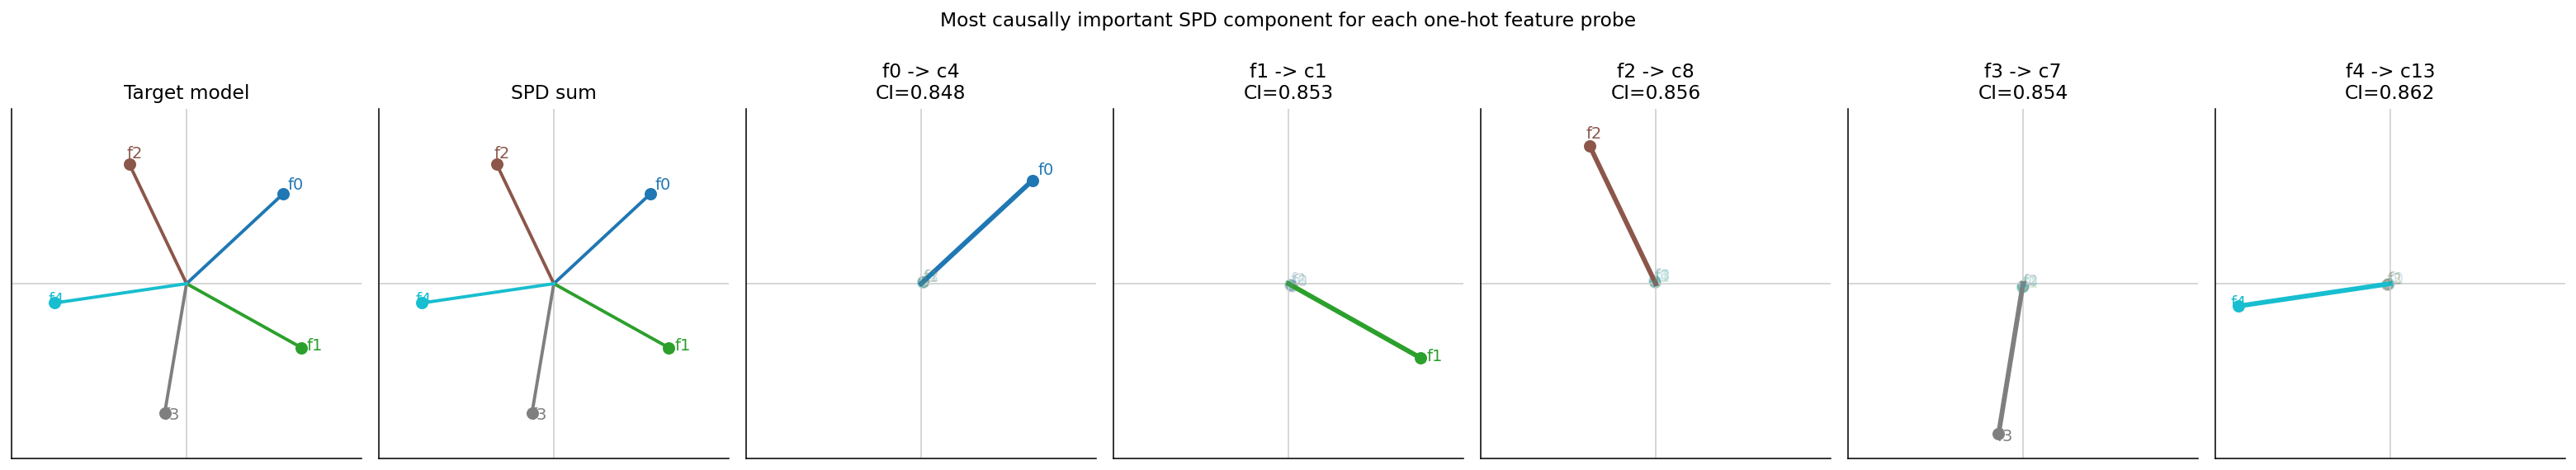

: 

: 

In [ ]:
ci_component_indices = ci_df['linear1_best_component'].tolist()
ci_component_vectors = [linear1_components[idx].T for idx in ci_component_indices]
plot_limit = vector_plot_limit([target_vectors, spd_sum_vectors, *ci_component_vectors])

fig, axes = plt.subplots(1, 2 + target_model.config.n_features, figsize=(3.2 * (2 + target_model.config.n_features), 4.0))
plot_vector_panel(axes[0], target_vectors, feature_colors, 'Target model', plot_limit)
plot_vector_panel(axes[1], spd_sum_vectors, feature_colors, 'SPD sum', plot_limit)
for feature_idx in range(target_model.config.n_features):
    component_idx = int(ci_df.iloc[feature_idx]['linear1_best_component'])
    ci_value = float(ci_df.iloc[feature_idx]['linear1_ci'])
    plot_vector_panel(
        axes[2 + feature_idx],
        linear1_components[component_idx].T,
        feature_colors,
        f'f{feature_idx} -> c{component_idx}\nCI={ci_value:.3f}',
        plot_limit,
        highlight_feature=feature_idx,
        reference_vectors=target_vectors,
    )
fig.suptitle('Most causally important SPD component for each one-hot feature probe', y=1.05)
fig.tight_layout()
plt.show()

### Reading the plots

- If the target model is truly tied, the cosine heatmap should be maximized on a one-to-one diagonal matching and the tie checks should show near-zero error.
- If SPD found the paper-style solution, the top few component norms should dominate and the top-`5` partial sum should already be extremely close to both `W1` and `W2`.
- In the final CI plot, each feature should ideally map to a distinct high-CI subcomponent whose highlighted direction lines up with the corresponding target feature direction.

## 6. TMS Hidden-Dimension Contributions

This is a TMS-specific analogue of the paper's neuron-contribution idea for the residual-MLP toy models.

For TMS, with `W1` as the input-to-hidden matrix and `W2` as the hidden-to-output matrix, define the contribution of hidden unit `h` to mapping input feature `j` into output feature `i` as:

```python
contrib[i, j, h] = W2[i, h] * W1[h, j]
```

Summing over hidden units gives the linear pre-ReLU map from input feature `j` to output feature `i`. Because `TMS_5-2` has only two hidden dimensions, this gives a compact way to inspect how the target model and the dominant SPD subcomponents route feature computations through the hidden space.


In [ ]:
def tms_hidden_contributions(W1: torch.Tensor, W2: torch.Tensor) -> torch.Tensor:
    assert W1.ndim == 2 and W2.ndim == 2
    assert W1.shape[0] == W2.shape[1]
    return torch.einsum('ih,hj->ijh', W2, W1)


def plot_hidden_contribution_heatmaps(contrib: torch.Tensor, title_prefix: str) -> None:
    n_hidden = contrib.shape[-1]
    vmax = float(contrib.abs().max().item())
    fig, axes = plt.subplots(1, n_hidden, figsize=(5 * n_hidden, 4))
    axes = np.atleast_1d(axes)
    for hidden_idx, ax in enumerate(axes):
        im = ax.imshow(as_numpy(contrib[:, :, hidden_idx]), cmap='coolwarm', vmin=-vmax, vmax=vmax)
        ax.set_title(f'{title_prefix} hidden unit {hidden_idx}')
        ax.set_xlabel('input feature j')
        ax.set_ylabel('output feature i')
        ax.set_xticks(range(contrib.shape[1]))
        ax.set_yticks(range(contrib.shape[0]))
    fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.025, pad=0.02, label='contribution')
    fig.tight_layout()
    plt.show()


def flatten_hidden_contributions(contrib: torch.Tensor) -> torch.Tensor:
    return contrib.reshape(contrib.shape[0] * contrib.shape[1], contrib.shape[2])


: 

: 

target_vs_spd_contrib_mse             1.19881e-08
target_vs_spd_contrib_max_abs_diff    2.28524e-04
dtype: float64

/var/folders/x0/2gdcc4dx06l26j8346nm7c5r0000gn/T/ipykernel_84012/953245997.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


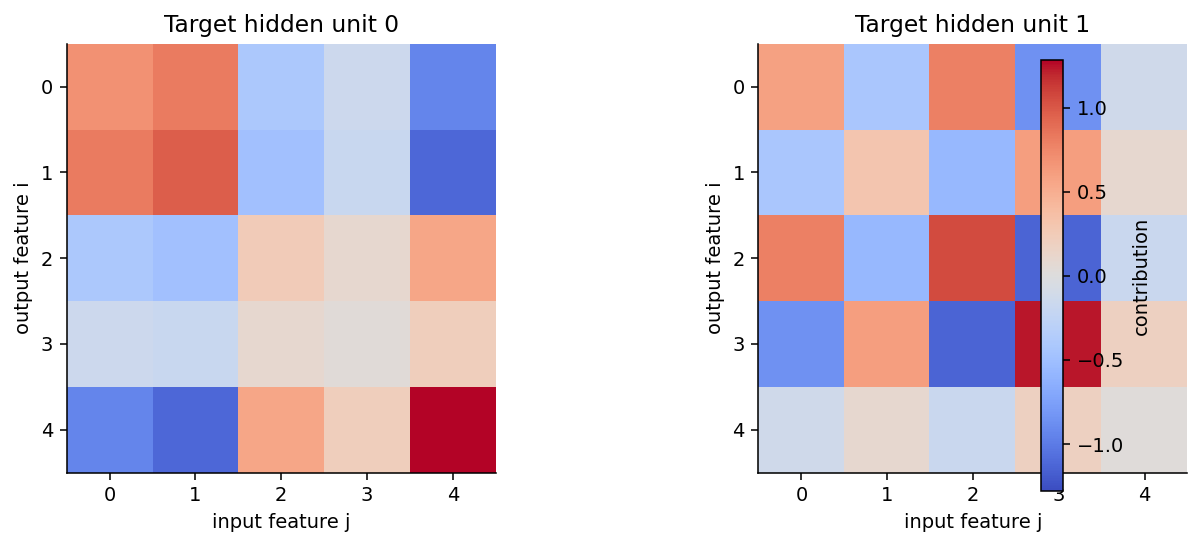

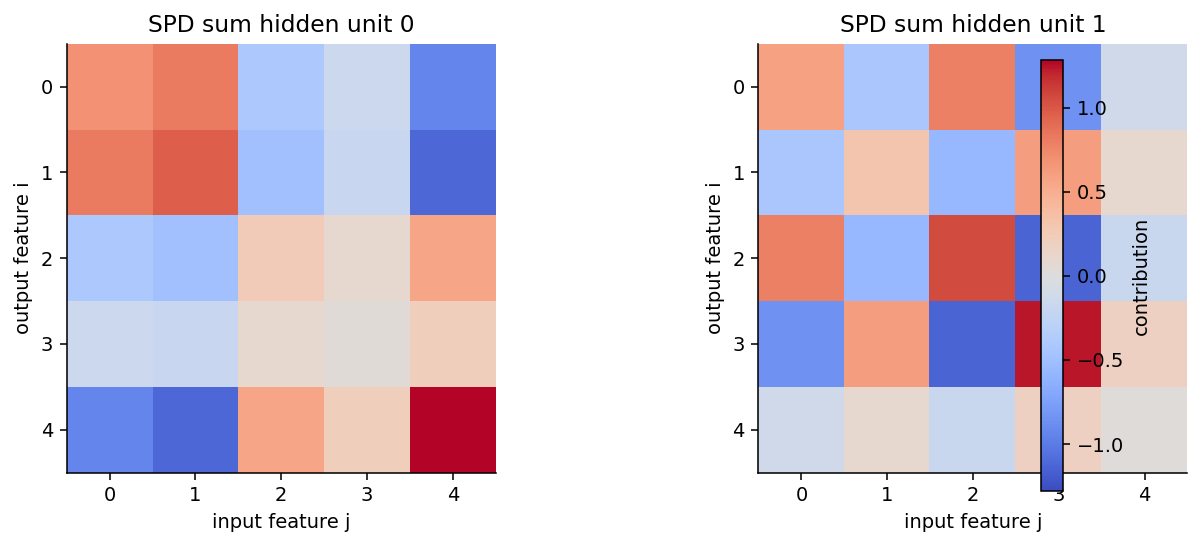

: 

: 

In [ ]:
target_hidden_contrib = tms_hidden_contributions(target_W1, target_W2)
spd_hidden_contrib = tms_hidden_contributions(spd_W1, spd_W2)

target_vs_spd_hidden_contrib = pd.Series(
    {
        'target_vs_spd_contrib_mse': float(torch.mean((target_hidden_contrib - spd_hidden_contrib).square()).item()),
        'target_vs_spd_contrib_max_abs_diff': float((target_hidden_contrib - spd_hidden_contrib).abs().max().item()),
    }
)
display(target_vs_spd_hidden_contrib)

plot_hidden_contribution_heatmaps(target_hidden_contrib, 'Target')
plot_hidden_contribution_heatmaps(spd_hidden_contrib, 'SPD sum')


In [ ]:
target_hidden_contrib_flat = flatten_hidden_contributions(target_hidden_contrib)

component_hidden_contrib_rows = []
for component_idx in linear1_order[:TOP_K_FOR_RECONSTRUCTION].tolist():
    contrib = tms_hidden_contributions(linear1_components[component_idx], linear2_components[component_idx])
    flat = flatten_hidden_contributions(contrib)
    cosine = cosine_similarity_matrix(target_hidden_contrib_flat, flat)
    component_hidden_contrib_rows.append(
        {
            'component_idx': component_idx,
            'component_norm': float(torch.norm(linear1_components[component_idx]).item()),
            'contrib_norm': float(torch.norm(contrib).item()),
            'mean_max_cos_to_target_pairs': float(cosine.max(dim=1).values.mean().item()),
            'contrib_mse_to_target': float(torch.mean((target_hidden_contrib - contrib).square()).item()),
        }
    )

hidden_contrib_component_df = pd.DataFrame(component_hidden_contrib_rows)
display(hidden_contrib_component_df)


,component_idx,component_norm,contrib_norm,mean_max_cos_to_target_pairs,contrib_mse_to_target
0,13,1.32016,1.70600,0.04840,0.38334
1,8,1.31467,1.44238,0.04415,0.39180
2,7,1.30779,1.66702,0.03561,0.38576
3,4,1.30532,1.20812,0.05853,0.39795
4,1,1.30064,1.34795,0.05580,0.39359


: 

: 

In [3]:
top_ci_component_indices = ci_df['linear1_best_component'].tolist()
fig, axes = plt.subplots(target_model.config.n_features, 3, figsize=(12, 3.2 * target_model.config.n_features))
axes = np.atleast_2d(axes)

for feature_idx in range(target_model.config.n_features):
    target_pair = target_hidden_contrib[:, feature_idx, :]
    ci_component_idx = top_ci_component_indices[feature_idx]
    ci_pair = tms_hidden_contributions(linear1_components[ci_component_idx], linear2_components[ci_component_idx])[:, feature_idx, :]
    topnorm_pair = tms_hidden_contributions(linear1_components[int(linear1_order[feature_idx].item())], linear2_components[int(linear2_order[feature_idx].item())])[:, feature_idx, :]

    pair_mats = [target_pair, ci_pair, topnorm_pair]
    titles = [
        f'f{feature_idx}: target',
        f'f{feature_idx}: CI-picked c{ci_component_idx}',
        f'f{feature_idx}: norm-ranked c{int(linear1_order[feature_idx].item())}',
    ]
    vmax = max(float(mat.abs().max().item()) for mat in pair_mats)

    for col_idx, (ax, mat, title) in enumerate(zip(axes[feature_idx], pair_mats, titles, strict=True)):
        im = ax.imshow(as_numpy(mat), cmap='coolwarm', vmin=-vmax, vmax=vmax)
        ax.set_title(title)
        ax.set_xlabel('hidden unit h')
        ax.set_ylabel('output feature i')
        ax.set_xticks(range(mat.shape[1]))
        ax.set_yticks(range(mat.shape[0]))

fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.015, pad=0.01, label='contribution')
fig.suptitle('Per-feature hidden-dimension contribution slices for target and SPD components', y=1.01)
fig.tight_layout()
plt.show()


NameError: name 'ci_df' is not defined

### Interpreting the contribution plots

- Each heatmap slice shows how a single hidden dimension contributes to mapping input feature `j` into output feature `i`.
- The target-vs-SPD-sum comparison should be nearly exact if the SPD decomposition is faithful.
- The per-feature comparison plots show whether a single dominant SPD component reproduces the same hidden-dimension routing pattern as the target for a chosen input feature.
- Unlike the residual-MLP toy models, this is a compact 2-hidden-unit analogue, so it is best interpreted as a geometric/routing diagnostic rather than a large-neuron circuit map.


## 7. Paper-Style Contribution Plots For TMS

These are the TMS analogues of the paper's contribution plots for compressed computation / distributed representations.

Because `TMS_5-2` only has 5 features and 2 hidden units, the plots are much smaller, but the same comparison is possible:

- top panel: target-model hidden-dimension contributions for each input feature
- bottom panel: the best-matching SPD subcomponent contribution pattern for each input feature
- scatter: all target contribution values vs the corresponding matched-subcomponent contribution values


In [4]:
if 'tms_hidden_contributions' not in globals():
    def tms_hidden_contributions(W1: torch.Tensor, W2: torch.Tensor) -> torch.Tensor:
        assert W1.ndim == 2 and W2.ndim == 2
        assert W1.shape[0] == W2.shape[1]
        return torch.einsum('ih,hj->ijh', W2, W1)

if 'target_hidden_contrib' not in globals():
    target_hidden_contrib = tms_hidden_contributions(target_W1, target_W2)
if 'spd_hidden_contrib' not in globals():
    spd_hidden_contrib = tms_hidden_contributions(spd_W1, spd_W2)

def flatten_feature_hidden_contribution(contrib: torch.Tensor, feature_idx: int) -> torch.Tensor:
    return contrib[:, feature_idx, :].reshape(-1)


def best_contribution_matching_components(
    target_hidden_contrib: torch.Tensor,
    linear1_components: torch.Tensor,
    linear2_components: torch.Tensor,
) -> tuple[list[int], list[float]]:
    best_indices: list[int] = []
    best_cosines: list[float] = []
    for feature_idx in range(target_hidden_contrib.shape[1]):
        target_vec = flatten_feature_hidden_contribution(target_hidden_contrib, feature_idx)
        scores: list[float] = []
        for component_idx in range(linear1_components.shape[0]):
            component_contrib = tms_hidden_contributions(
                linear1_components[component_idx],
                linear2_components[component_idx],
            )
            component_vec = flatten_feature_hidden_contribution(component_contrib, feature_idx)
            cosine = torch.dot(target_vec, component_vec) / (
                torch.norm(target_vec) * torch.norm(component_vec) + 1e-12
            )
            scores.append(float(cosine.item()))
        best_component_idx = max(range(len(scores)), key=lambda idx: scores[idx])
        best_indices.append(best_component_idx)
        best_cosines.append(scores[best_component_idx])
    return best_indices, best_cosines


matched_component_indices, matched_component_cosines = best_contribution_matching_components(
    target_hidden_contrib,
    linear1_components,
    linear2_components,
)
contrib_match_df = pd.DataFrame(
    {
        'feature': list(range(target_model.config.n_features)),
        'matched_component': matched_component_indices,
        'cosine_to_target_contrib': matched_component_cosines,
    }
)
display(contrib_match_df)


NameError: name 'target_hidden_contrib' is not defined

NameError: name 'target_hidden_contrib' is not defined

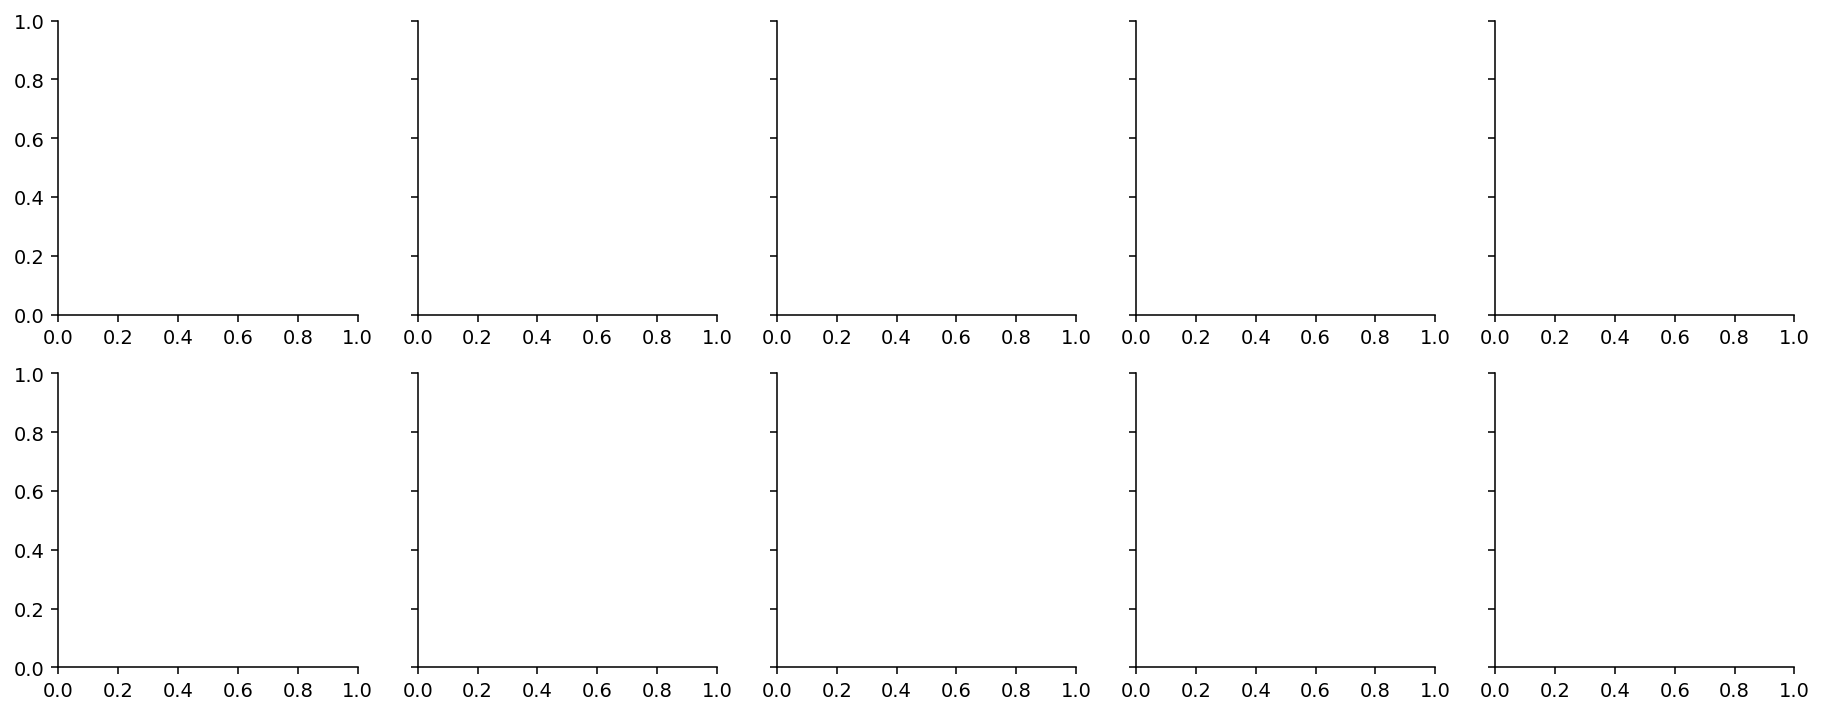

In [5]:
if 'tms_hidden_contributions' not in globals():
    def tms_hidden_contributions(W1: torch.Tensor, W2: torch.Tensor) -> torch.Tensor:
        assert W1.ndim == 2 and W2.ndim == 2
        assert W1.shape[0] == W2.shape[1]
        return torch.einsum('ih,hj->ijh', W2, W1)

if 'target_hidden_contrib' not in globals():
    target_hidden_contrib = tms_hidden_contributions(target_W1, target_W2)
if 'matched_component_indices' not in globals():
    matched_component_indices, matched_component_cosines = best_contribution_matching_components(
        target_hidden_contrib,
        linear1_components,
        linear2_components,
    )

hidden_colors = list(plt.colormaps['Set1'](np.linspace(0, 1, target_model.config.n_hidden)))
output_markers = ['o', 's', '^', 'D', 'P']

fig, axes = plt.subplots(2, target_model.config.n_features, figsize=(3.2 * target_model.config.n_features, 6), sharey=True)
axes = np.atleast_2d(axes)

y_min = float(target_hidden_contrib.min().item())
y_max = float(target_hidden_contrib.max().item())
pad = 0.05 * max(abs(y_min), abs(y_max), 1e-6)

for feature_idx in range(target_model.config.n_features):
    target_slice = target_hidden_contrib[:, feature_idx, :]
    matched_idx = matched_component_indices[feature_idx]
    matched_slice = tms_hidden_contributions(linear1_components[matched_idx], linear2_components[matched_idx])[:, feature_idx, :]

    for output_idx in range(target_slice.shape[0]):
        for hidden_idx in range(target_slice.shape[1]):
            axes[0, feature_idx].scatter(
                hidden_idx,
                target_slice[output_idx, hidden_idx].item(),
                color=hidden_colors[hidden_idx],
                marker=output_markers[output_idx],
                s=55,
                alpha=0.9,
            )
            axes[1, feature_idx].scatter(
                hidden_idx,
                matched_slice[output_idx, hidden_idx].item(),
                color=hidden_colors[hidden_idx],
                marker=output_markers[output_idx],
                s=55,
                alpha=0.9,
            )

    axes[0, feature_idx].set_title(f'Target f{feature_idx}')
    axes[1, feature_idx].set_title(f'c{matched_idx} for f{feature_idx}')
    axes[0, feature_idx].set_xticks(range(target_model.config.n_hidden))
    axes[1, feature_idx].set_xticks(range(target_model.config.n_hidden))
    axes[0, feature_idx].axhline(0.0, color='#bbbbbb', linestyle='--', linewidth=0.8)
    axes[1, feature_idx].axhline(0.0, color='#bbbbbb', linestyle='--', linewidth=0.8)
    axes[0, feature_idx].set_ylim(y_min - pad, y_max + pad)
    axes[1, feature_idx].set_ylim(y_min - pad, y_max + pad)
    axes[1, feature_idx].set_xlabel('hidden unit h')

axes[0, 0].set_ylabel('target contribution')
axes[1, 0].set_ylabel('matched subcomponent contribution')
fig.suptitle('TMS analogue of the paper\'s top/bottom contribution panels', y=1.02)
fig.tight_layout()
plt.show()


all_target_vals: list[float] = []
all_matched_vals: list[float] = []
feature_colors = list(plt.colormaps['tab10'](np.linspace(0, 1, target_model.config.n_features)))
fig, ax = plt.subplots(figsize=(6.5, 6))
for feature_idx in range(target_model.config.n_features):
    matched_idx = matched_component_indices[feature_idx]
    target_vec = flatten_feature_hidden_contribution(target_hidden_contrib, feature_idx)
    matched_vec = flatten_feature_hidden_contribution(
        tms_hidden_contributions(linear1_components[matched_idx], linear2_components[matched_idx]),
        feature_idx,
    )
    all_target_vals.extend(target_vec.tolist())
    all_matched_vals.extend(matched_vec.tolist())
    ax.scatter(target_vec.tolist(), matched_vec.tolist(), color=feature_colors[feature_idx], s=45, alpha=0.85, label=f'f{feature_idx}')

all_target_np = np.array(all_target_vals)
all_matched_np = np.array(all_matched_vals)
correlation = float(np.corrcoef(all_target_np, all_matched_np)[0, 1])
line_min = min(all_target_np.min(), all_matched_np.min())
line_max = max(all_target_np.max(), all_matched_np.max())
ax.plot([line_min, line_max], [line_min, line_max], linestyle='--', color='#999999', linewidth=1.0, label='y = x')
ax.text(0.03, 0.97, f'Correlation: {correlation:.3f}', transform=ax.transAxes, va='top', bbox={'facecolor': '#f3ead7', 'edgecolor': '#b8aa8c'})
ax.set_title('TMS target contributions vs matched SPD subcomponent contributions')
ax.set_xlabel('Target hidden-dimension contribution')
ax.set_ylabel('Matched subcomponent contribution')
ax.legend(loc='lower right', fontsize=8)
fig.tight_layout()
plt.show()

: 

: 